<a href="https://colab.research.google.com/github/SarthoPramanik1075/Deep-Learning/blob/main/DL_Mid_Term_Exam_Sol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# DL Mid term exam

**Name:** Mohammad Asif

**Course Email:** asif.phitron@gmail.com

## End of Assignment

Before submitting:
- Run all cells from top to bottom.  
- Check that all answer sections are filled.  
- Instruction video অনুযায়ী আমাদের দেয়া Colab ফাইলটি থেকে প্রথম একটি Save copy in drive করে নিবা। এরপর Google colab এর মধ্যে কোডগুলো করবে এবং সেই ফাইলটি ‘Anyone with the link’ & ‘View’ Access দিয়ে ফাইলটির Shareble Link টি সাবমিট করবে।

# Question 01: [ Marks 10 ]

Draw a Neural Network

Draw a neural network with:

3 input features

3 hidden layers (at least 2 neurons each)

1 output neuron

a) Label all weights and biases. <br>
b) Write the forward equations layer by layer. <br>
c) If output uses Sigmoid, write the final prediction equation. <br>

Please note : Don't forget to attach a screen short of your neural network.

##Write Answer 01: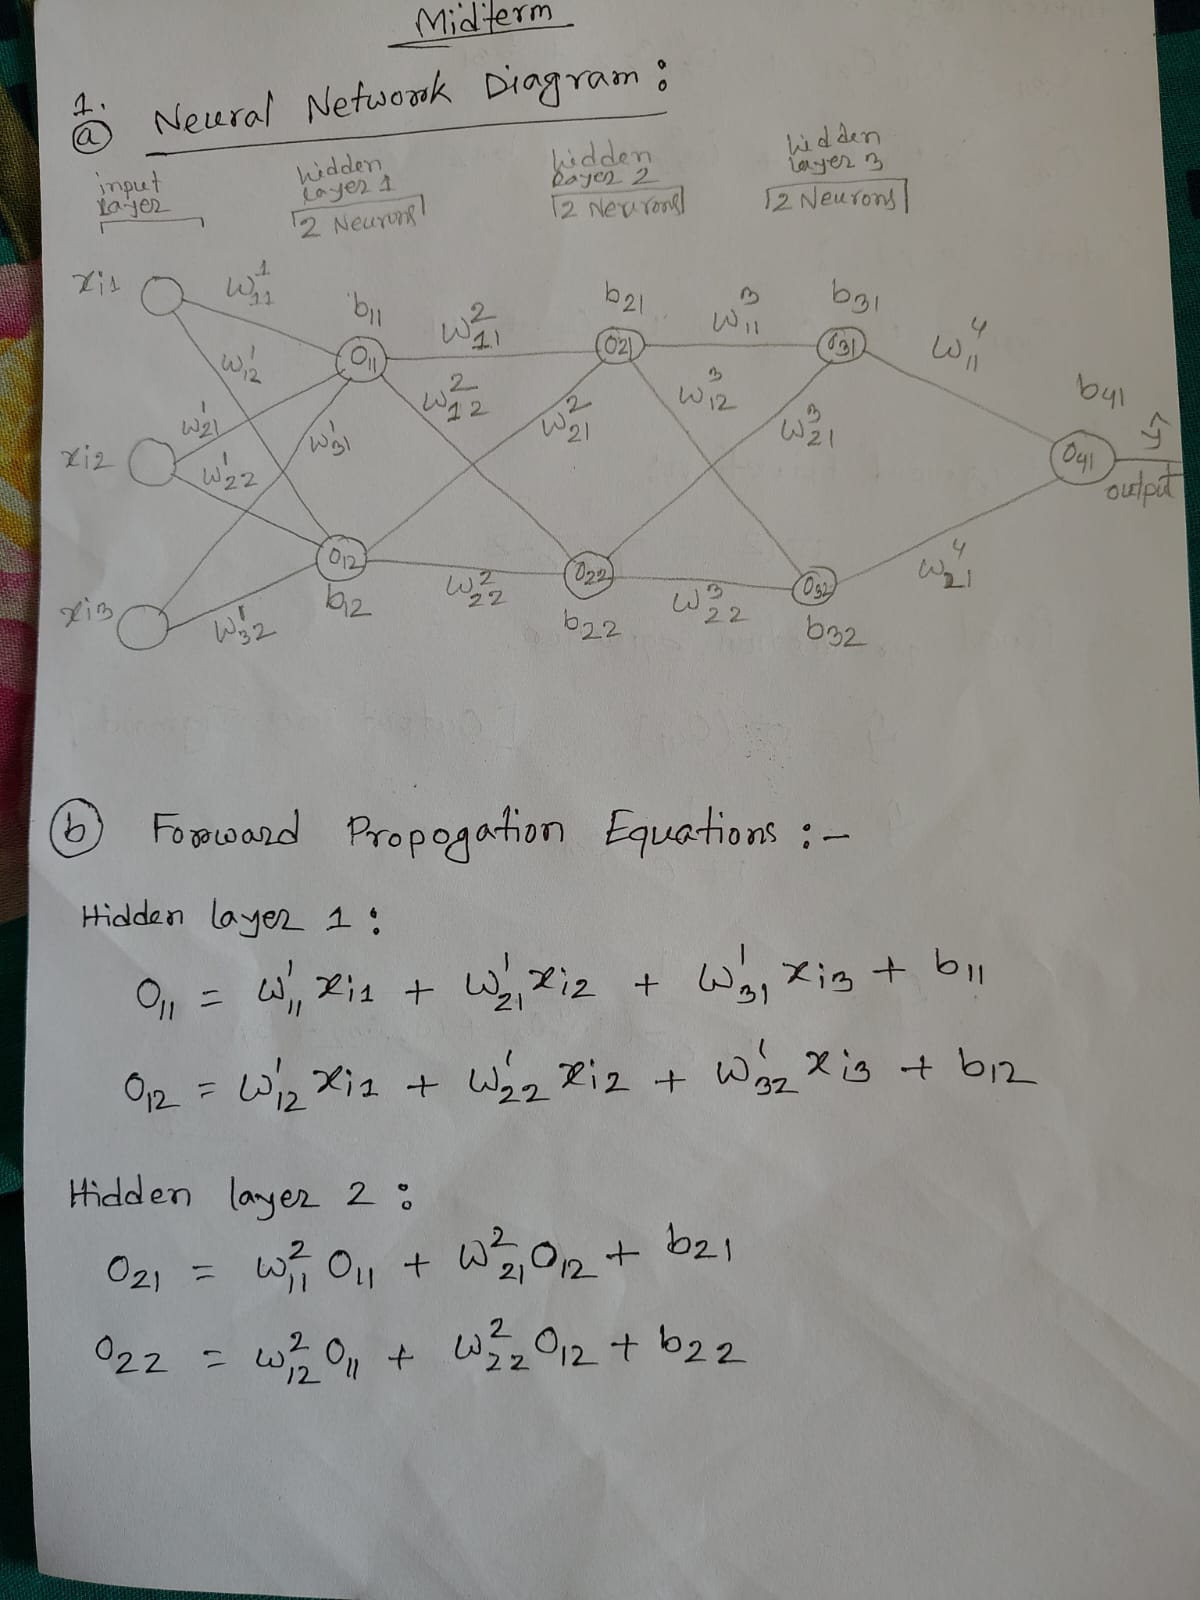

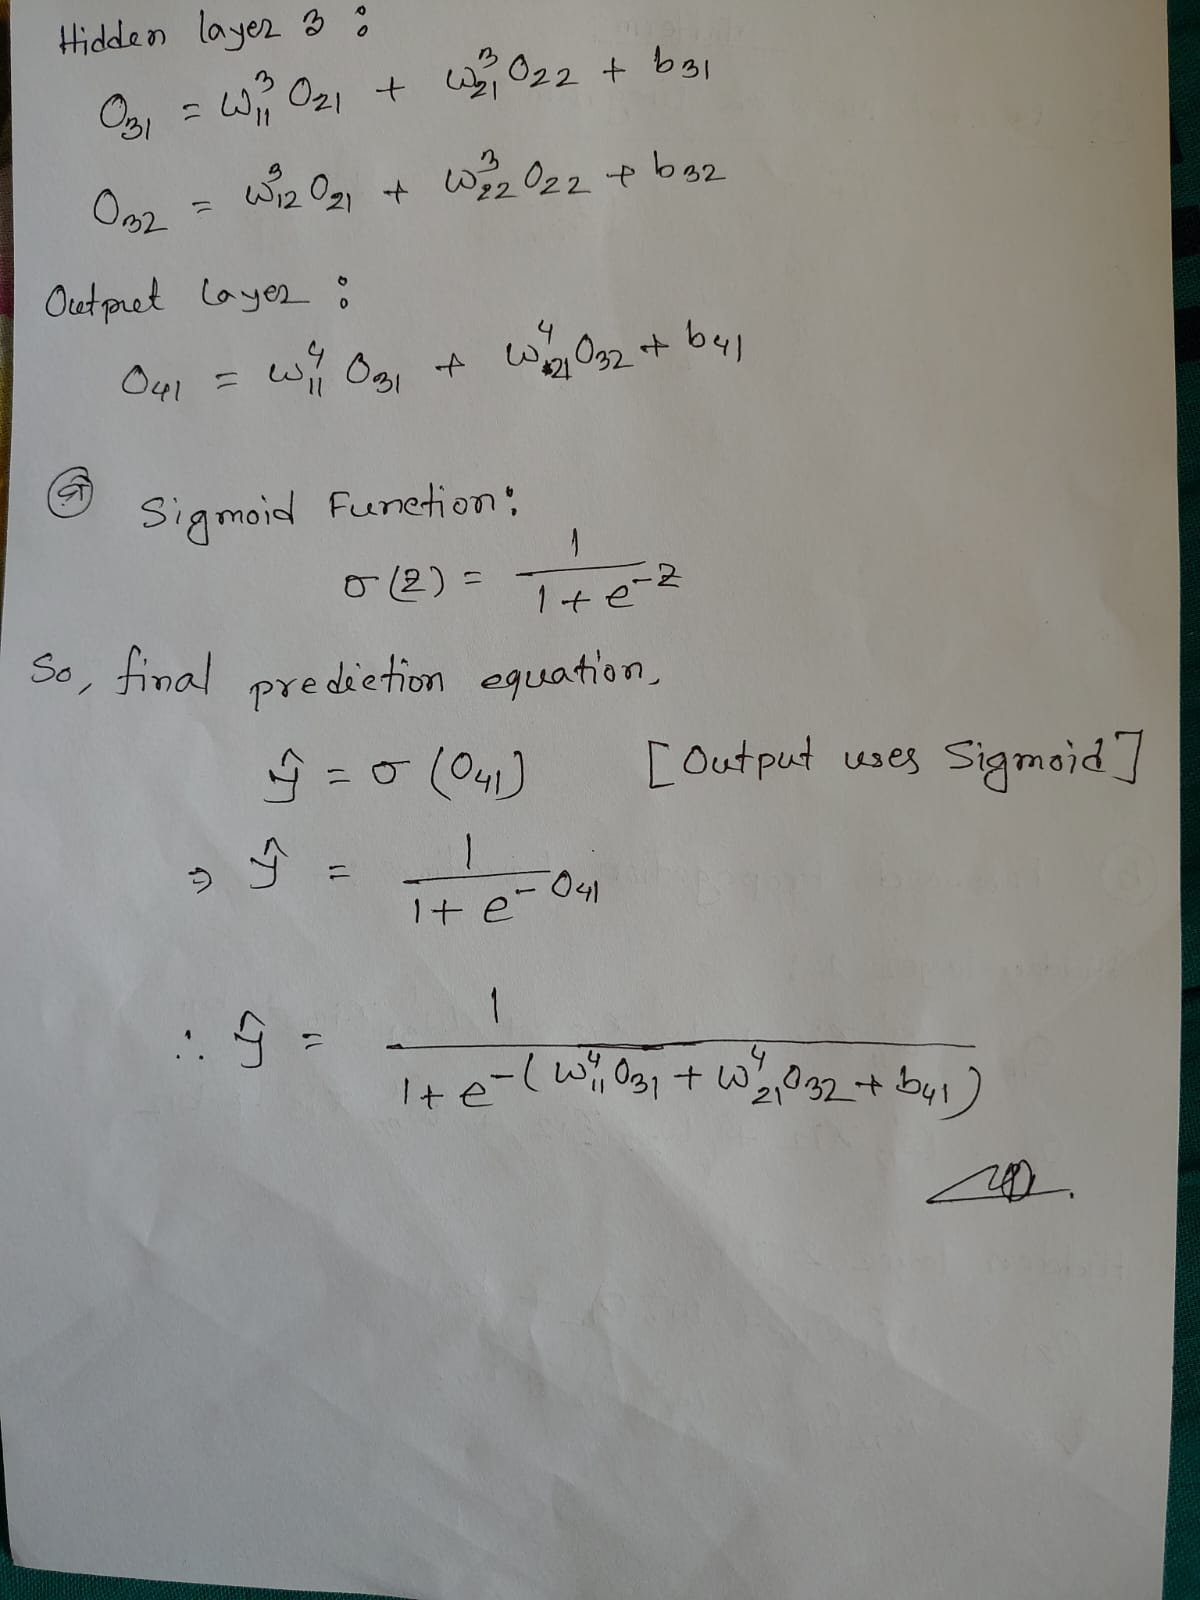

# Question 02: [ Marks 20 ]

Manual Gradient Calculation

Given:

z = w*x + b <br>
y_pred = sigmoid(z) <br>
L = −[ y log(y_pred) + (1−y) log(1−y_pred) ] <br>

a) Write dL/dy_pred <br>
b) Write dy_pred/dz <br>
c) Show that dL/dz = y_pred − y <br>

## Write Answer 02:


In [1]:
import numpy as np


x = 2.0
w = 0.5
b = 1.0
y = 1


z = w * x + b


def sigmoid(z):
    return 1 / (1 + np.exp(-z))

y_pred = sigmoid(z)

L = - (y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))


#a
dL_dypred = (y_pred - y) / (y_pred * (1 - y_pred))
print("a. dL/dy_pred =", dL_dypred)

#b
dypred_dz = y_pred * (1 - y_pred)
print("b. dy_pred/dz =", dypred_dz)

#c
dL_dz = dL_dypred * dypred_dz
print("c. dL/dz =", dL_dz)

a. dL/dy_pred = -1.1353352832366128
b. dy_pred/dz = 0.10499358540350662
c. dL/dz = -0.11920292202211769


# Question 03: [ Marks 15 ]

x = 3
y1 = x^2
y2 = 4*x
L = y1 + y2

a) Draw the computation graph. <br>
b) Compute dL/dx manually. <br>
c) Explain how would you do it using Autograd <br>

## Write Answer 03:
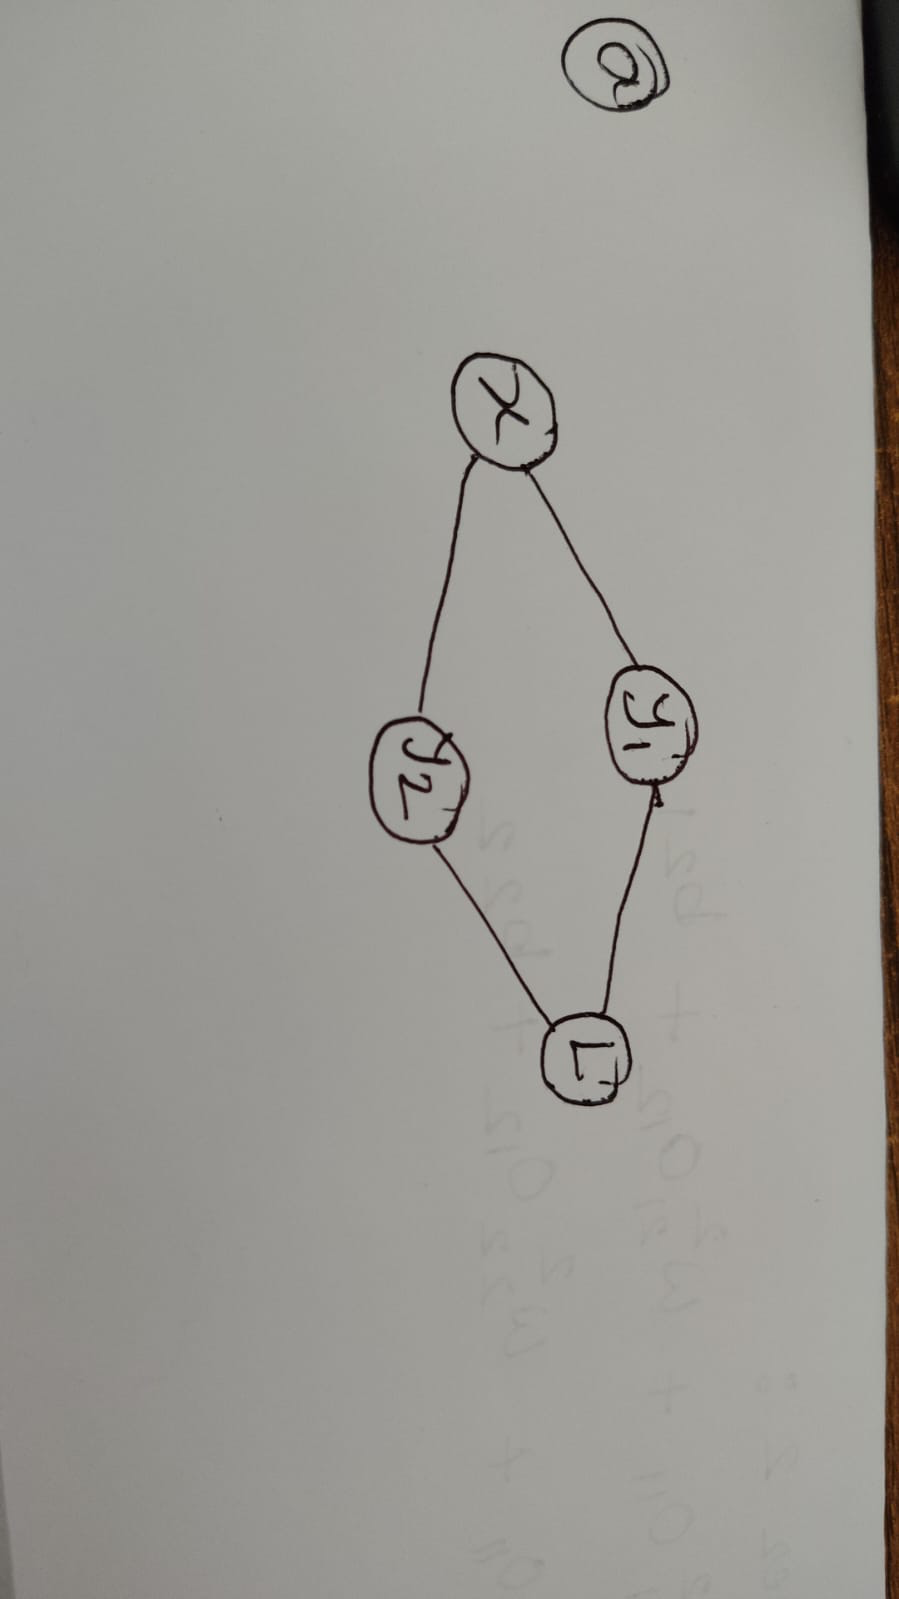

In [2]:
import numpy as np
import torch

x = 3.0

y1 = x**2
y2 = 4 * x
L = y1 + y2

#b
def dL_dx(L):
  return 2 * x + 4

print("b. dL/dx =", dL_dx(L))


#c
x = torch.tensor(3.0, requires_grad=True)
y1 = x**2
y2 = 4*x
L = y1 + y2

L.backward()
x.grad

print("c. Using autograd dL/dx =", x.grad)

b. dL/dx = 10.0
c. Using autograd dL/dx = tensor(10.)


# Question 04: [ Marks 15 ]

Create a scalar tensor x = 3.0 with gradient tracking enabled. <br>
Compute y = x² + 4x. <br>
Perform backpropagation. <br>
Print the gradient of x. <br>

Write the full PyTorch code yourself. <br>

## Write Answer 04:

In [3]:
import torch

x = torch.tensor(3.0, requires_grad=True)


y = x**2 + 4*x

y.backward()

print("Gradient of x =", x.grad)

Gradient of x = tensor(10.)


# Question 05: [ Marks 10 ]

Create two tensors:
w = 2.0 (requires_grad=True) <br>
b = 1.0 (requires_grad=True) <br>

Let input x = 3.0. <br>
Compute z = w*x + b. <br>
Use Sigmoid to get y_pred.
 <br>

Define Binary Cross Entropy manually (without built-in loss). <br>
Compute gradients using backward(). <br>
Print gradients of w and b. <br>

Write full code.

## Write Answer 05:


In [4]:
import torch

w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

x = torch.tensor(3.0)
y = torch.tensor(1.0)

z = w * x + b

y_pred = 1 / (1 + torch.exp(-z))

L = - (y * torch.log(y_pred) + (1 - y) * torch.log(1 - y_pred))

L.backward()

print("Gradient of w =", w.grad)
print("Gradient of b =", b.grad)

Gradient of w = tensor(-0.0027)
Gradient of b = tensor(-0.0009)


# Question 06: [ Marks 10 ]

Create a tensor x = 2.0 (requires_grad=True). <br>
Compute:

y1 = x² <br>
y2 = 3x <br>
L = y1 + y2 <br>

Call backward(). <br>
Print x.grad. <br>

Write full PyTorch code.

## Write Answer 06:

In [5]:
import torch

x = torch.tensor(2.0, requires_grad=True)

y1 = x**2
y2 = 3 * x
L = y1 + y2

L.backward()

print("Gradient of x =", x.grad)

Gradient of x = tensor(7.)


# Question 07: [ Marks 20 ]


Create tensor w = 2.0 (requires_grad=True). <br>

Compute two different losses sequentially and call backward() twice. <br>
Print w.grad. <br>

Do not clear gradients. <br>
Explain what you observe. <br>

Write full code.


## Write Answer 07:

#When backward() is called multiple times without clearing gradients, PyTorch accumulates the gradients instead of replacing them.

In [6]:
import torch

w = torch.tensor(2.0, requires_grad=True)


L1 = w**2
L1.backward()

print("After first backward, grad =", w.grad)

L2 = 3 * w
L2.backward()

print("After second backward, grad =", w.grad)

After first backward, grad = tensor(4.)
After second backward, grad = tensor(7.)
